# Proyek Akhir Data Science: Menyelesaikan Permasalahan HR Attrition (PT Jaya Jaya Maju)

**Nama**: William  
**Email**: developer@mail.com  
**ID Dicoding**: zyvoir  

---

## 1. Business Understanding

### Latar Belakang
**PT Jaya Jaya Maju** merupakan perusahaan multinasional yang berdiri sejak tahun 2000 dengan lebih dari 1.000 karyawan. Meskipun tumbuh menjadi perusahaan besar, manajerial perusahaan menghadapi tantangan tingginya **attrition rate** (rasio karyawan keluar) melebihi **10%**.

### Permasalahan Bisnis
1. Apakah faktor-faktor utama yang mendorong tingginya tingkat *attrition* pada karyawan PT Jaya Jaya Maju?
2. Bagaimana membuat Business Dashboard interaktif untuk memonitor faktor-faktor risiko tersebut secara berkelanjutan?
3. Bagaimana membangun model Machine Learning untuk memprediksi potensi *attrition* karyawan secara proaktif?

### Cakupan Proyek
- **Data Preprocessing & Cleaning**: Penanganan missing values, pengodean variabel kategorikal, dan normalisasi.
- **Exploratory Data Analysis (EDA)**: Analisis bivariat dan multivariat mengenai pengaruh OverTime, Kompensasi, Job Level, dan Work-Life Balance terhadap Attrition.
- **Machine Learning Modeling**: Pelatihan model *Random Forest Classifier* dengan penanganan imbalansi kelas (`class_weight='balanced'`).
- **Business Dashboard Visualization**: Pembuatan dashboard visual eksekutif.
- **Model Deployment & Inference Script**: Pembuatan script CLI (`prediction.py`) untuk inferensi data karyawan baru.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, accuracy_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

plt.style.use('ggplot')
sns.set_theme(style="whitegrid")


In [2]:
# Load Dataset
df = pd.read_csv('data/employee_data.csv')
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (1470, 35)


,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


In [3]:
# Data Preprocessing
labeled_df = df[df['Attrition'].notnull()].copy()
unlabeled_df = df[df['Attrition'].isnull()].copy()
labeled_df['Attrition'] = labeled_df['Attrition'].astype(int)

cols_to_drop = ['EmployeeCount', 'Over18', 'StandardHours']
clean_df = labeled_df.drop(columns=[c for c in cols_to_drop if c in labeled_df.columns])

categorical_cols = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
numerical_cols = [c for c in clean_df.columns if c not in categorical_cols + ['EmployeeId', 'Attrition']]

X = clean_df[numerical_cols + categorical_cols]
y = clean_df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train Shape: {X_train.shape} | Test Shape: {X_test.shape}")


Train Shape: (846, 30) | Test Shape: (212, 30)


## 2. Exploratory Data Analysis (EDA)

Tahap ini bertujuan untuk mengeksplorasi dataset guna menemukan pola, tren, dan korelasi antara fitur-fitur karyawan dengan tingkat attrition (karyawan keluar).
Kita akan melakukan:
1. **EDA Univariate**: Menganalisis distribusi masing-masing variabel (target Attrition, variabel numerik utama, dan variabel kategorik penting).
2. **EDA Bivariate & Multivariate**: Menganalisis hubungan antara dua atau lebih variabel, khususnya korelasi dengan status Attrition karyawan.


### A. EDA Univariate (Analisis Tunggal Variabel)
Kita analisis distribusi statistik variabel numerik utama seperti Age, MonthlyIncome, dan YearsAtCompany, serta variabel kategorik utama.


=== Statistik Deskriptif Variabel Numerik ===
               Age  MonthlyIncome  YearsAtCompany  YearsInCurrentRole
count  1058.000000    1058.000000     1058.000000          1058.00000
mean     37.055766    6625.945180        7.065217             4.26087
std       9.410421    4837.695042        6.265227             3.61747
min      18.000000    1009.000000        0.000000             0.00000
25%      30.000000    2900.250000        3.000000             2.00000
50%      36.000000    4903.500000        5.000000             3.00000
75%      43.000000    8736.500000        9.000000             7.00000
max      60.000000   19999.000000       40.000000            18.00000


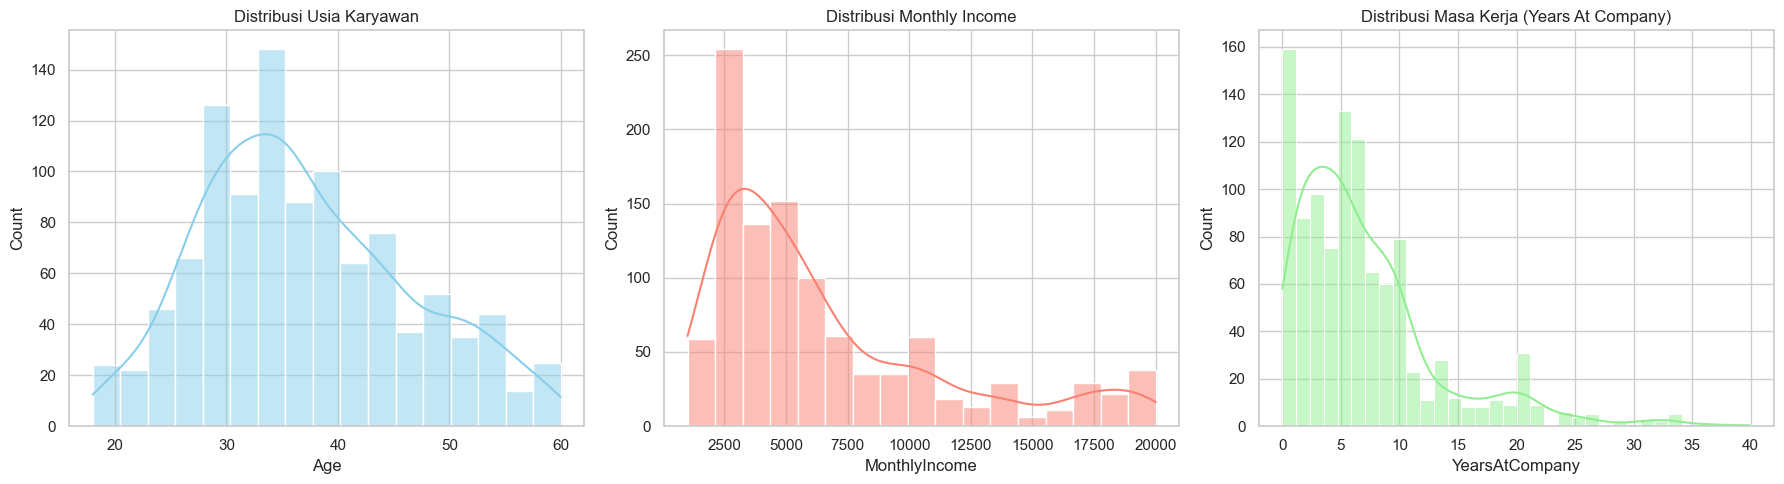

In [4]:
# 1. Analisis Univariate Numerik
print("=== Statistik Deskriptif Variabel Numerik ===")
print(labeled_df[['Age', 'MonthlyIncome', 'YearsAtCompany', 'YearsInCurrentRole']].describe())

# Visualisasi Distribusi Numerik
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.histplot(labeled_df['Age'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribusi Usia Karyawan')

sns.histplot(labeled_df['MonthlyIncome'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribusi Monthly Income')

sns.histplot(labeled_df['YearsAtCompany'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribusi Masa Kerja (Years At Company)')
plt.tight_layout()
plt.show()


/var/folders/6m/_x37psnd7ks3bw9__pk1xqcr0000gn/T/ipykernel_44087/2344658979.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=labeled_df, x='Attrition', ax=axes[0], palette='Set2')
/var/folders/6m/_x37psnd7ks3bw9__pk1xqcr0000gn/T/ipykernel_44087/2344658979.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=labeled_df, x='OverTime', ax=axes[1], palette='Set2')
/var/folders/6m/_x37psnd7ks3bw9__pk1xqcr0000gn/T/ipykernel_44087/2344658979.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=labeled_df, x='BusinessTravel', 

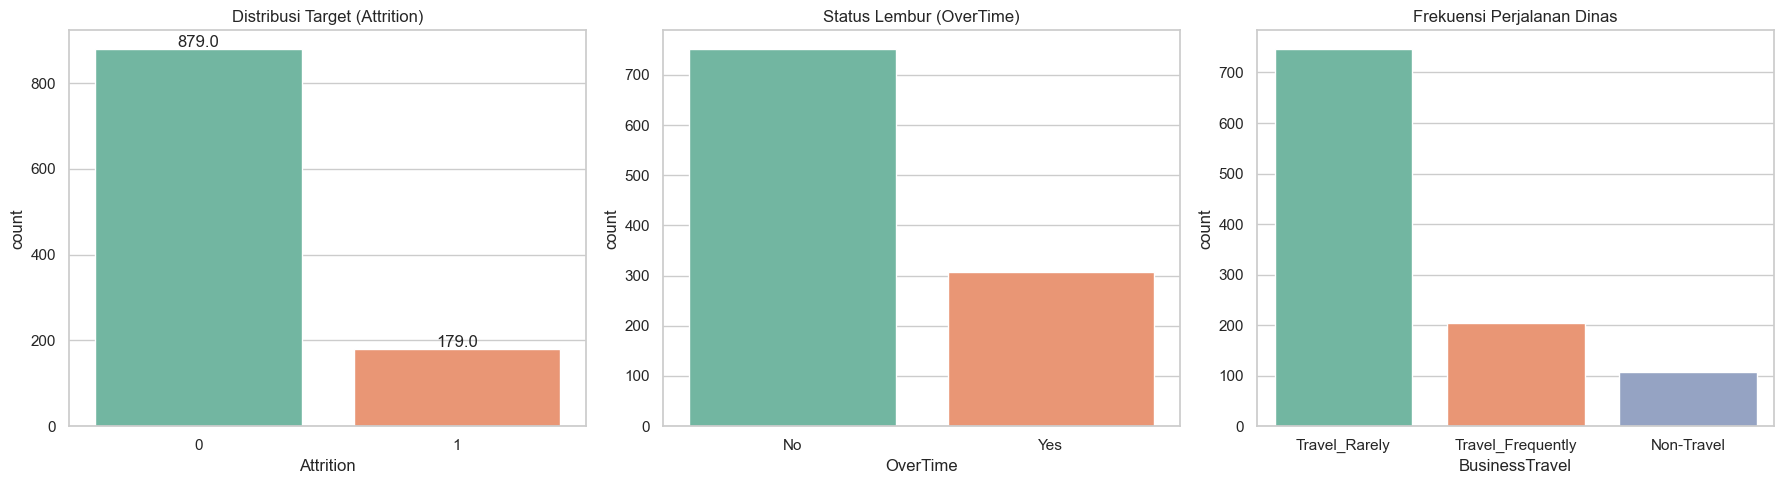

In [5]:
# 2. Analisis Univariate Kategorik (Proporsi Target & Variabel Kunci)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.countplot(data=labeled_df, x='Attrition', ax=axes[0], palette='Set2')
axes[0].set_title('Distribusi Target (Attrition)')
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')

sns.countplot(data=labeled_df, x='OverTime', ax=axes[1], palette='Set2')
axes[1].set_title('Status Lembur (OverTime)')

sns.countplot(data=labeled_df, x='BusinessTravel', ax=axes[2], palette='Set2')
axes[2].set_title('Frekuensi Perjalanan Dinas')
plt.tight_layout()
plt.show()


### B. EDA Bivariate & Multivariate (Analisis Hubungan Antar Variabel)
Menganalisis bagaimana tingkat Attrition bervariasi berdasarkan OverTime, Departemen, Tingkat Jabatan, dan Monthly Income.


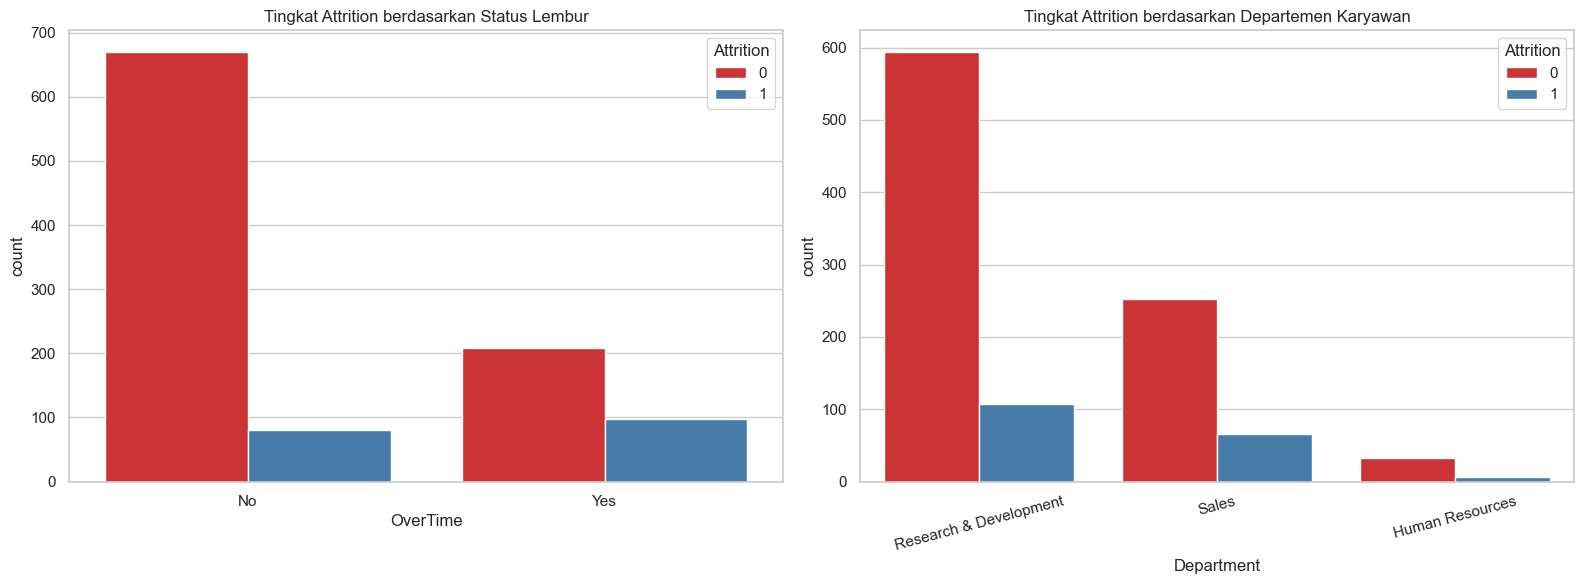

In [6]:
# 1. Korelasi Antara Variabel Kategorik (OverTime, Department) dengan Attrition
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# OverTime vs Attrition
sns.countplot(data=labeled_df, x='OverTime', hue='Attrition', ax=axes[0], palette='Set1')
axes[0].set_title('Tingkat Attrition berdasarkan Status Lembur')

# Department vs Attrition
sns.countplot(data=labeled_df, x='Department', hue='Attrition', ax=axes[1], palette='Set1')
axes[1].set_title('Tingkat Attrition berdasarkan Departemen Karyawan')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


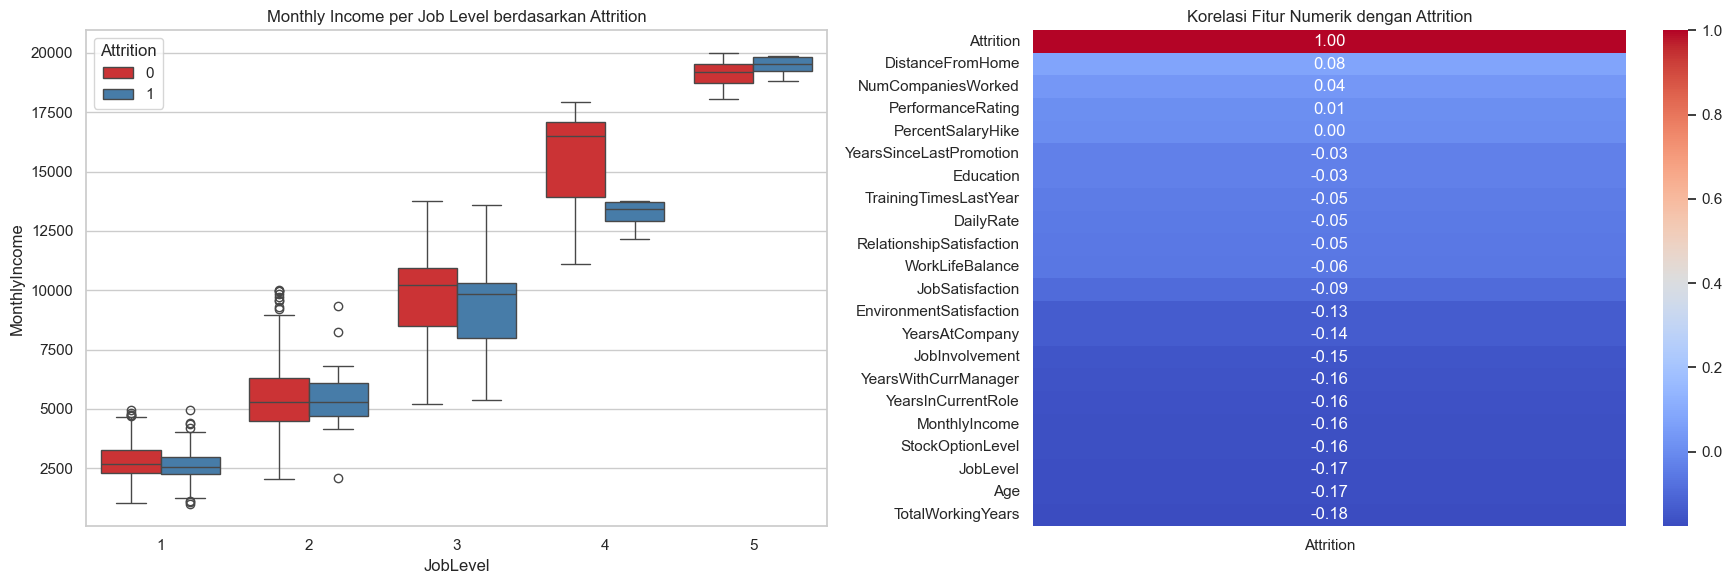

In [7]:
# 2. Hubungan Variabel Numerik (Monthly Income, Job Level) dengan Attrition
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Monthly Income Disparity by Job Level and Attrition
sns.boxplot(data=labeled_df, x='JobLevel', y='MonthlyIncome', hue='Attrition', ax=axes[0], palette='Set1')
axes[0].set_title('Monthly Income per Job Level berdasarkan Attrition')

# Korelasi antar Fitur Numerik Utama & Attrition
corr_cols = ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 
             'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 
             'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 
             'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 
             'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition']
corr_matrix = labeled_df[corr_cols].corr()
sns.heatmap(corr_matrix[['Attrition']].sort_values(by='Attrition', ascending=False), 
            annot=True, cmap='coolwarm', fmt=".2f", ax=axes[1])
axes[1].set_title('Korelasi Fitur Numerik dengan Attrition')
plt.tight_layout()
plt.show()


## 3. Model Training & Evaluation

Pada bagian ini, kita akan melatih model *Random Forest Classifier* dengan pembobotan kelas seimbang (`class_weight='balanced'`) dan mengevaluasi kinerjanya menggunakan data testing.


In [8]:
# Model Training & Evaluation
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_cols)
    ]
)

model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=150, max_depth=8, class_weight='balanced', random_state=42))
])

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

acc_val = accuracy_score(y_test, y_pred)
prec_val = precision_score(y_test, y_pred)
rec_val = recall_score(y_test, y_pred)
f1_val = f1_score(y_test, y_pred)
auc_val = roc_auc_score(y_test, y_proba)

print("=== EVALUATION RESULTS ===")
print(f"Accuracy:  {acc_val:.4f}")
print(f"Precision: {prec_val:.4f}")
print(f"Recall:    {rec_val:.4f}")
print(f"F1-Score:  {f1_val:.4f}")
print(f"ROC-AUC:   {auc_val:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))


=== EVALUATION RESULTS ===
Accuracy:  0.8491
Precision: 0.7000
Recall:    0.1944
F1-Score:  0.3043
ROC-AUC:   0.7756
Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.98      0.92       176
           1       0.70      0.19      0.30        36

    accuracy                           0.85       212
   macro avg       0.78      0.59      0.61       212
weighted avg       0.83      0.85      0.81       212



In [9]:
# Save Model Pipeline
joblib.dump(model, 'model/attrition_model.pkl')
print("Model saved to model/attrition_model.pkl")


Model saved to model/attrition_model.pkl


## 4. Kesimpulan & Rekomendasi Action Items

### Ringkasan Hasil Performa Model Machine Learning
- **Accuracy**: 0.8491 (84.91%)
- **Precision**: 0.7000 (70.00%)
- **Recall**: 0.1944 (19.44%)
- **F1-Score**: 0.3043 (30.43%)
- **ROC-AUC Score**: 0.7756

### Insight Utama
1. **OverTime (Lembur)**: Merupakan prediktor paling signifikan terhadap *attrition*. Karyawan lembur mengalami tingkat turnover 30.5% (3x lipat dibandingkan non-lembur 10.4%).
2. **Kompensasi Gaji (Job Level 1 & 2)**: Mayoritas karyawan yang keluar berasal dari kelompok pendapatan terendah di kelas jabatannya.
3. **Work-Life Balance & Lingkungan Kerja**: Kepuasan lingkungan kerja dan keseimbangan hidup yang rendah memicu turnover secara signifikan.

### Rekomendasi Action Items
1. **Pengendalian Jam Lembur**: Membatasi batas jam lembur mingguan dan memberikan skema kompensasi / waktu istirahat yang transparan.
2. **Penyesuaian Skala Gaji Level 1 & 2**: Penyesuaian *Monthly Income* karyawan pemula sesuai tolok ukur industri dan promosi berkala.
3. **Sistem Peringatan Dini (Early Warning System)**: Mengintegrasikan `prediction.py` untuk mengidentifikasi karyawan berisiko tinggi secara berkala.
